In [1]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key="9X8ClVkM9agUJAH3hcAN")
project = rf.workspace("hard-drive").project("hdd_process_states")
version = project.version(5)
dataset = version.download("folder")

DATA_PATH = dataset.location

loading Roboflow workspace...
loading Roboflow project...


In [2]:
import splitfolders

OUTPUT_DIR = "dataset_cls_split"

# This will automatically read the class folders inside 'train' 
# and split them into train/val/test directories.
splitfolders.ratio(
    os.path.join(DATA_PATH, "train"), 
    output=OUTPUT_DIR, 
    seed=42, 
    ratio=(.8, .1, .1), # 80% Train, 10% Val, 10% Test
    group_prefix=None
)

print(f"✅ Classification dataset split successfully into {OUTPUT_DIR}/")

Copying files: 1225 files [00:00, 6780.52 files/s]

✅ Classification dataset split successfully into dataset_cls_split/


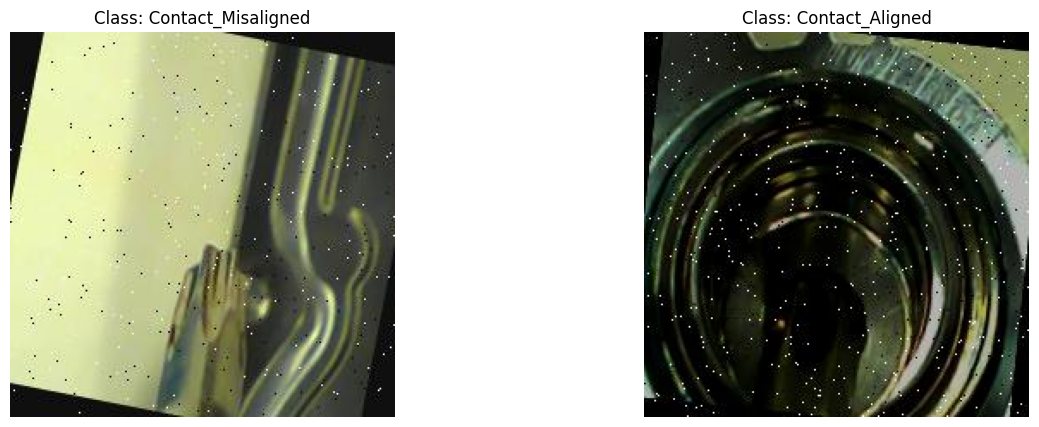

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Get the list of classes (folder names)
train_dir = os.path.join(OUTPUT_DIR, "train")
classes = os.listdir(train_dir)

plt.figure(figsize=(15, 5))

# Plot one random image from each class
for i, cls_name in enumerate(classes):
    cls_path = os.path.join(train_dir, cls_name)
    images = os.listdir(cls_path)
    if images:
        random_image = random.choice(images)
        img_path = os.path.join(cls_path, random_image)
        
        plt.subplot(1, len(classes), i + 1)
        img = mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Class: {cls_name}")

plt.show()

In [4]:
from ultralytics import YOLO

# Load the SOTA YOLO11 Nano Classification model
# (You can use yolo11s-cls.pt if you need slightly more accuracy)
model = YOLO("yolo11n-cls.pt")

# Train the model
results = model.train(
    data=OUTPUT_DIR,       # Pass the root folder containing train/val/test
    epochs=100,
    imgsz=640,             # Keep resolution high to see tiny screw threads
    batch=32,              # Classification is very lightweight, batch 32 easily fits in 8GB VRAM
    device=0,
    project="HDD_Disassembly",
    name="YOLO11_Referee_Cls",
    patience=30,           
    save=True
)

Ultralytics 8.4.21 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7940MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_cls_split, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11_Referee_Cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [5]:
# Load the best classification weights
best_model = YOLO("runs/classify/HDD_Disassembly/YOLO11_Referee_Cls/weights/best.pt")

# Validate on the validation set
metrics = best_model.val()

print("\n--- REFEREE VALIDATION RESULTS ---")
print(f"Top-1 Accuracy: {metrics.top1:.4f}")
print(f"Top-5 Accuracy: {metrics.top5:.4f}")

Ultralytics 8.4.21 🚀 Python-3.10.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7940MiB)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /home/adip/workspace/disassembly_ws/src/vision_training/Project 3 (Classification)/yolo11/dataset_cls_split/train... found 979 images in 2 classes ✅ 
val: /home/adip/workspace/disassembly_ws/src/vision_training/Project 3 (Classification)/yolo11/dataset_cls_split/val... found 121 images in 2 classes ✅ 
test: /home/adip/workspace/disassembly_ws/src/vision_training/Project 3 (Classification)/yolo11/dataset_cls_split/test... found 125 images in 2 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1428.9±497.7 MB/s, size: 9.0 KB)
val: Scanning /home/adip/workspace/disassembly_ws/src/vision_training/Project 3 (Classification)/yolo11/dataset_cls_split/val... 121 images, 0 corrupt: 100% ━━━━━━━━━━━━ 121/121 39.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 8

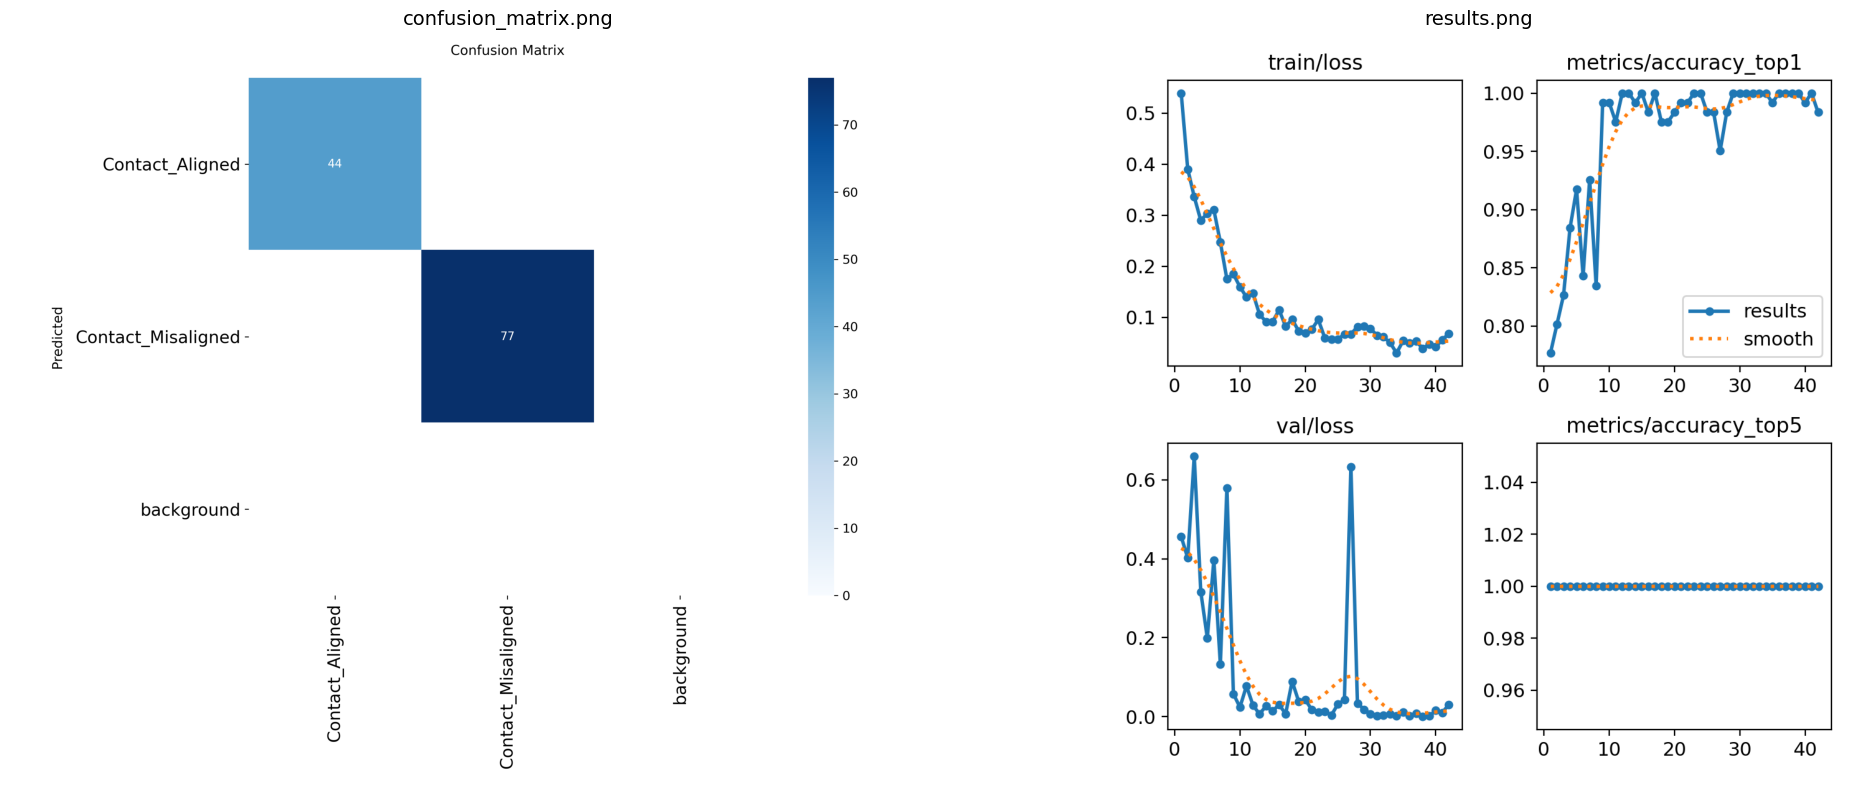

In [7]:
res_path = "runs/classify/HDD_Disassembly/YOLO11_Referee_Cls/"

# Classification generates different charts than object detection
plots = ['confusion_matrix.png', 'results.png']

plt.figure(figsize=(20, 8))
for i, plot in enumerate(plots):
    full_path = os.path.join(res_path, plot)
    if os.path.exists(full_path):
        plt.subplot(1, 2, i+1)
        img = mpimg.imread(full_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot, fontsize=14)
    else:
        print(f"⚠️ {plot} not found.")

plt.tight_layout()
plt.show()


image 1/1 /home/adip/workspace/disassembly_ws/src/vision_training/Project 3 (Classification)/yolo11/dataset_cls_split/test/Contact_Misaligned/25-1_mp4-0005_jpg.rf.e6a1815c03389540788e1822ef1bf60f.jpg: 640x640 Contact_Misaligned 1.00, Contact_Aligned 0.00, 1.8ms
Speed: 4.9ms preprocess, 1.8ms inference, 0.0ms postprocess per image at shape (1, 3, 640, 640)


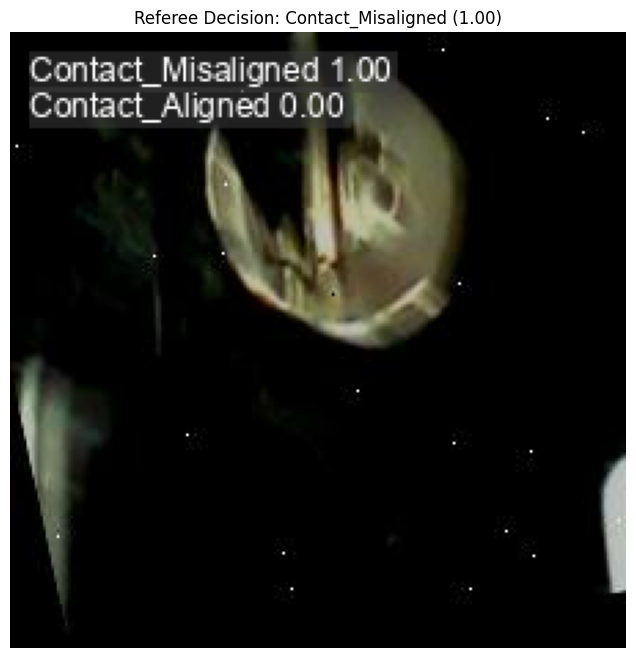

In [8]:
import cv2

# Grab a random test image
test_class_dir = os.path.join(OUTPUT_DIR, 'test', classes[0])
test_img_name = os.listdir(test_class_dir)[0]
test_img_path = os.path.join(test_class_dir, test_img_name)

# Run Inference
results = best_model.predict(test_img_path)

# Extract top prediction
top_class_id = results[0].probs.top1
top_class_name = best_model.names[top_class_id]
confidence = float(results[0].probs.top1conf)

# Render results
res_plotted = results[0].plot()
res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(res_rgb)
plt.axis('off')
plt.title(f"Referee Decision: {top_class_name} ({confidence:.2f})")
plt.show()